## Generar espectros

In [1]:
import multirex as mrex
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import pandas as pd
import os
import re
import gc
import warnings
import joblib

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def remove_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)

from sklearn.model_selection import train_test_split

waves=np.loadtxt("waves.txt")
n_points = len(waves)
indices = np.linspace(0, len(waves) - 1, n_points, endpoint=True)
indices = np.round(indices).astype(int)  # Redondear los índices y convertir a entero

# Seleccionar los elementos de la lista usando los índices
puntos_seleccionados = waves[indices]
waves=puntos_seleccionados
wn_grid=np.sort((10000/waves))

Loading MultiREx version 0.3.1


## load data

In [2]:
import os
import re
import numpy as np
import pandas as pd

def apply_contaminations_from_files(contamination_files, df, n_points, include_no_contam=False):
    """
    Applies multiple contaminations to the data from a list of contamination files
    and returns a DataFrame with all combinations.

    Parameters:
        contamination_files (list of str): Paths to .txt files containing contaminations.
                                           Expected name pattern: ...fspot<val>_ffac<val>.txt
                                           e.g. epsilon_T3400_fspot0.000_ffac0.000.txt
        df (pandas.DataFrame): Original DataFrame to apply contaminations.
        n_points (int): Number of columns to which the contamination will be applied.
        include_no_contam (bool): If True, also include an explicit non-contaminated
                                  copy (f_spot=0, f_fac=0). If there is also a file
                                  with f_spot=0 and f_fac=0, that file is skipped
                                  to avoid duplicating the same case.

    Returns:
        pandas.DataFrame: DataFrame with all combinations of contaminations, with
        additional columns 'f_spot' and 'f_fac'. Also sets:
            - df_final.data   -> last n_points columns
            - df_final.params -> all other columns
    """
    df_list = []

    # Opción: incluir caso no contaminado "puro" (sin leer de archivo)
    if include_no_contam:
        df_no_contam = df.copy()
        df_no_contam["f_spot"] = 0.0
        df_no_contam["f_fac"] = 0.0
        # Reordenar columnas: primero f_spot, f_fac
        cols = ["f_spot", "f_fac"] + [
            col for col in df_no_contam.columns if col not in ["f_spot", "f_fac"]
        ]
        df_no_contam = df_no_contam[cols]
        df_list.append(df_no_contam)

    # Regex para extraer f_spot y f_fac del nombre:
    # ...fspot<value>_ffac<value>.txt  (el prefijo da igual)
    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        # Verificar que el archivo exista
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"The file {file_path} does not exist.")

        # Extraer f_spot y f_fac del nombre
        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if not match:
            raise ValueError(f"The file name '{filename}' does not match the expected pattern.")

        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        # Si ya incluimos un caso no contaminado "puro", evitamos duplicar el (0,0) del archivo
        if include_no_contam and f_spot == 0.0 and f_fac == 0.0:
            continue

        # Leer datos de contaminación
        try:
            contamination_data = np.loadtxt(file_path, ndmin=2)

            # Columna de epsilon: si hay ≥2 columnas, usamos la segunda
            if contamination_data.shape[1] >= 2:
                contam_values = contamination_data[:, 1]
            else:
                contam_values = contamination_data.flatten()

            # Chequear longitud
            if len(contam_values) != n_points:
                raise ValueError(
                    f"The number of contamination values in '{filename}' ({len(contam_values)}) "
                    f"does not match n_points ({n_points})."
                )
        except Exception as e:
            raise ValueError(f"Error reading the file {file_path}: {e}")

        # (Opcional) invertir orden si tu matriz de datos está al revés en λ
        contam_values = contam_values[::-1]

        # Aplicar contaminación multiplicativa a las últimas n_points columnas
        df_contam = df.copy()
        data_columns = df_contam.columns[-n_points:]
        df_contam[data_columns] = df_contam[data_columns].multiply(contam_values, axis=1)

        # Añadir parámetros de cobertura
        df_contam["f_spot"] = f_spot
        df_contam["f_fac"] = f_fac

        # Reordenar columnas
        cols = ["f_spot", "f_fac"] + [
            col for col in df_contam.columns if col not in ["f_spot", "f_fac"]
        ]
        df_contam = df_contam[cols]

        df_list.append(df_contam)

    # Concatenar todos los casos
    df_final = pd.concat(df_list, ignore_index=True)

    # Atributos convenientes para usar luego
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]

    return df_final


In [3]:
import joblib
import pandas as pd
import glob

# Cargar el dataset base de K2-18b
k2_18b = joblib.load("specs/k2-18b_data.joblib")

## replace Nan with 0 in  'atm CO2', 'atm CH4','atm H2O', 'atm NH3',
k2_18b[
    ['atm CO2', 'atm CH4','atm H2O', 'atm NH3']
    ] = k2_18b[
        ['atm CO2', 'atm CH4','atm H2O', 'atm NH3']].fillna(0)



In [4]:
# Código corregido para crear espectro plano manteniendo .data y .params
flat = k2_18b[(k2_18b["atm CO2"] == -10) &
              (k2_18b["atm CH4"] == 0) &
              (k2_18b["atm H2O"] == 0) &
              (k2_18b["atm NH3"] == 0)].iloc[0:1].copy()

# Establecer las últimas n_points columnas a 0 (espectro plano)
flat["atm CO2"] = 0
flat.iloc[0, -n_points:] = 0.0023243496509944973

# Mantener tu asignación de .data y .params como la tienes
flat.data = flat.iloc[:, -n_points:]
flat.params = flat.iloc[:, :-n_points]

flat

C:\Users\User\AppData\Local\Temp\ipykernel_52232\760291980.py:12: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  flat.data = flat.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_52232\760291980.py:13: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  flat.params = flat.iloc[:, :-n_points]


,sma,seed,p_radius,p_mass,p_seed,atm temperature,atm base_pressure,atm top_pressure,atm fill_gas,atm cia,...,0.764875,0.756764,0.748855,0.741148,0.733644,0.726317,0.71918,0.712225,0.705435,0.698805
19466,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,"[H2, He]","[H2-H2, H2-He]",...,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324,0.002324


In [5]:
# Todos los archivos de contaminación generados antes:
# TLS/epsilon_T{T}_fspot{...}_ffac{...}.txt
contamination_files = sorted(
    glob.glob("TLS/epsilon_T*_fspot*_ffac*.txt")
)

print(f"N archivos de contaminación encontrados: {len(contamination_files)}")


N archivos de contaminación encontrados: 48


In [6]:
remove_warnings()  # si ya lo tienes definido en tu código

# 2) Aplicar TODAS las contaminaciones del listado a ese df
try:
    k2_18b_contam = apply_contaminations_from_files(
        contamination_files,
        k2_18b,
        n_points=n_points,  # usa el mismo n_points que en el resto del pipeline
    )
    print("Contaminaciones aplicadas correctamente a k2_18b.")
    print("Shape final:", k2_18b_contam.shape)
    print("Columnas params:", k2_18b_contam.params.columns[:10])
    print("n_points (espectro):", k2_18b_contam.data.shape[1])
except Exception as e:
    print(f"Error processing k2_18b: {e}")


flat_contam = apply_contaminations_from_files(
        contamination_files,
        flat,
        n_points=n_points,  # usa el mismo n_points que en el resto del pipeline
    )


C:\Users\User\AppData\Local\Temp\ipykernel_52232\1714951230.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_52232\1714951230.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_52232\1714951230.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

Contaminaciones aplicadas correctamente a k2_18b.
Shape final: (1058400, 409)
Columnas params: Index(['f_spot', 'f_fac', 'sma', 'seed', 'p_radius', 'p_mass', 'p_seed',
       'atm temperature', 'atm base_pressure', 'atm top_pressure'],
      dtype='object')
n_points (espectro): 385


C:\Users\User\AppData\Local\Temp\ipykernel_52232\1714951230.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_52232\1714951230.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_fac"] = f_fac
C:\Users\User\AppData\Local\Temp\ipykernel_52232\1714951230.py:92: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

In [7]:
k2_18b_contam

,f_spot,f_fac,sma,seed,p_radius,p_mass,p_seed,atm temperature,atm base_pressure,atm top_pressure,...,0.764875,0.756764,0.748855,0.741148,0.733644,0.726317,0.71918,0.712225,0.705435,0.698805
0,0.0,0.0,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002405,0.002406,0.002407,0.002408,0.002409,0.002410,0.002411,0.002412,0.002413,0.002414
1,0.0,0.0,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002405,0.002406,0.002407,0.002408,0.002409,0.002411,0.002412,0.002412,0.002413,0.002414
2,0.0,0.0,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002405,0.002406,0.002407,0.002408,0.002410,0.002412,0.002413,0.002412,0.002413,0.002414
3,0.0,0.0,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002405,0.002406,0.002407,0.002409,0.002413,0.002417,0.002417,0.002413,0.002415,0.002416
4,0.0,0.0,0.1429,1763714816,2.461,7.2,1763714816,250,1000000.0,0.001,...,0.002405,0.002406,0.002407,0.002412,0.002422,0.002430,0.002428,0.002418,0.002420,0.002420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1058395,0.3,0.4,0.1429,1763714816,2.461,7.2,1763714816,450,1000000.0,0.001,...,0.002736,0.002689,0.002700,0.002690,0.002709,0.002751,0.002706,0.002725,0.002710,0.002691
1058396,0.3,0.4,0.1429,1763714816,2.461,7.2,1763714816,450,1000000.0,0.001,...,0.002736,0.002689,0.002701,0.002690,0.002711,0.002754,0.002709,0.002725,0.002711,0.002692
1058397,0.3,0.4,0.1429,1763714816,2.461,7.2,1763714816,450,1000000.0,0.001,...,0.002736,0.002690,0.002702,0.002694,0.002718,0.002762,0.002717,0.002729,0.002714,0.002694
1058398,0.3,0.4,0.1429,1763714816,2.461,7.2,1763714816,450,1000000.0,0.001,...,0.002735,0.002690,0.002706,0.002703,0.002731,0.002778,0.002733,0.002739,0.002723,0.002700


## Clean data

In [8]:
def mult_df(df, n_points, n_mult):
    """
    Duplicates the DataFrame n_mult+1 times with additional columns 'f_spot' and 'f_fac'
    set to 0.0. The final DataFrame has .data and .params attributes defined based on
    the last n_points columns.
    """
    df_list = []
    for _ in range(n_mult + 1):
        # Non-contaminated case
        df_no_contam = df.copy()
        df_no_contam["f_spot"] = 0.0
        df_no_contam["f_fac"] = 0.0
        # Reorder columns to place 'f_spot' and 'f_fac' at the beginning
        cols = ["f_spot", "f_fac"] + [col for col in df_no_contam.columns if col not in ["f_spot", "f_fac"]]
        df_no_contam = df_no_contam[cols]
        df_list.append(df_no_contam)

    df_final = pd.concat(df_list, ignore_index=True)
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]

    return df_final

In [9]:
# Número de copias: por ejemplo, igual al número de contaminaciones
n_mult = len(contamination_files) -1
k2_18b_mult = mult_df(k2_18b, n_points=385, n_mult=n_mult)

flat_mult = mult_df(flat, n_points=385, n_mult=n_mult)

print(k2_18b_mult.shape)
print(k2_18b_mult.params.columns[:10])
print(k2_18b_mult.data.shape)


C:\Users\User\AppData\Local\Temp\ipykernel_52232\876726031.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_52232\876726031.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :-n_points]


(1058400, 409)
Index(['f_spot', 'f_fac', 'sma', 'seed', 'p_radius', 'p_mass', 'p_seed',
       'atm temperature', 'atm base_pressure', 'atm top_pressure'],
      dtype='object')
(1058400, 385)


C:\Users\User\AppData\Local\Temp\ipykernel_52232\876726031.py:19: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_52232\876726031.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :-n_points]


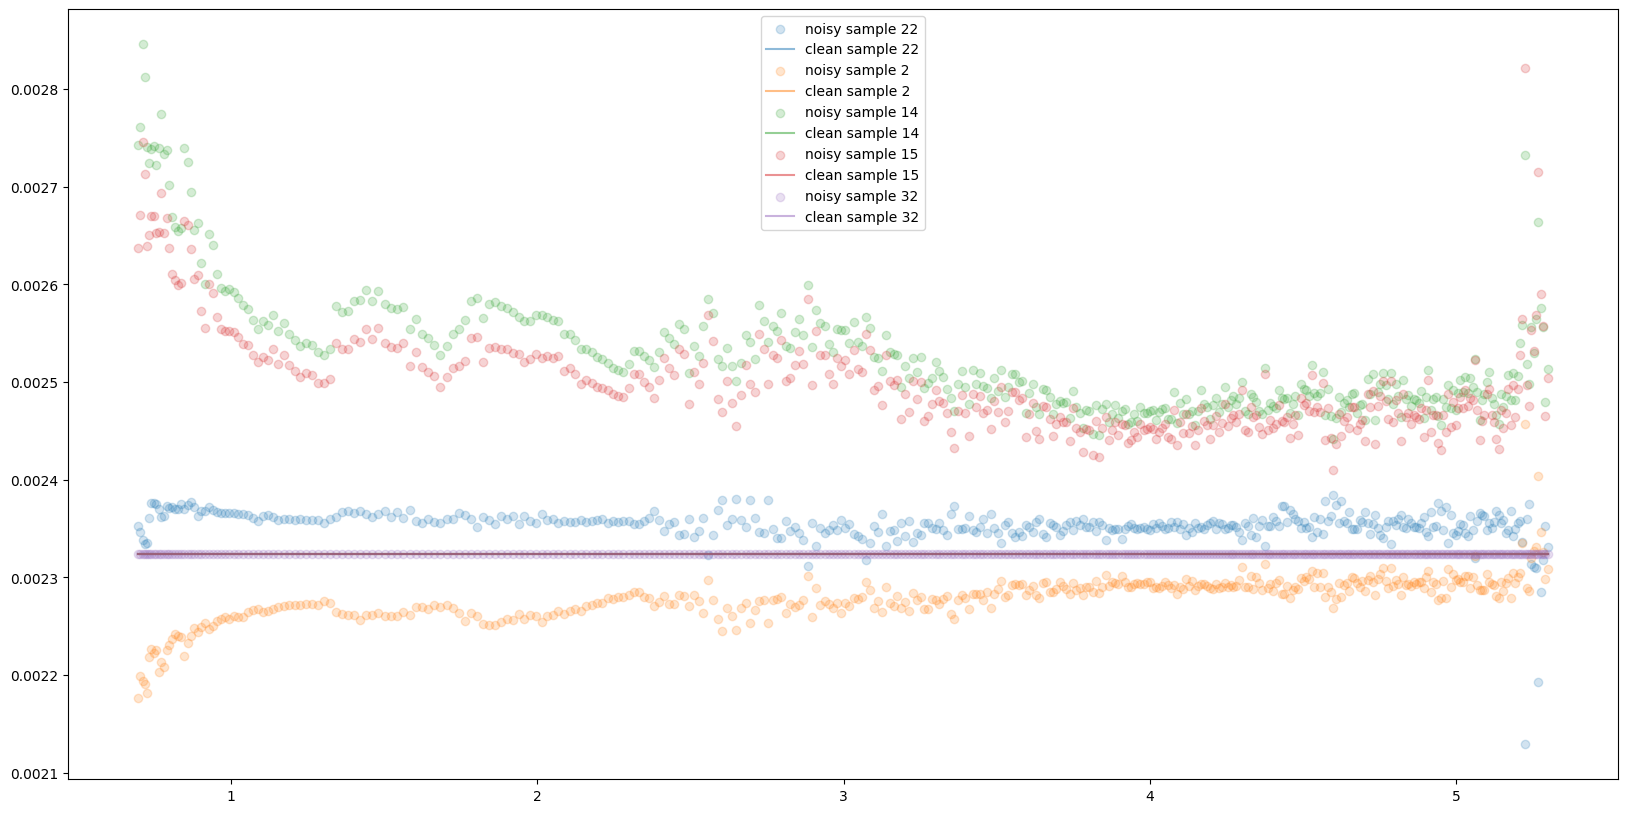

In [10]:
## plot samples of T1
plt.figure(figsize=(20, 10))

columns = flat_contam.columns[-n_points:]
for _ in range(5):
    idx = np.random.randint(0, flat_contam.shape[0])
    plt.scatter(columns, flat_contam.iloc[idx, -n_points:],
    alpha=0.2, label=f"noisy sample {idx}")

    plt.plot(flat_mult.iloc[idx, -n_points:],
    alpha=0.5, label=f"clean sample {idx}")

plt.legend()
plt.show()


In [11]:
def normalize_min_max_by_row(df):
    min_by_row = df.min(axis=1)
    max_by_row = df.max(axis=1)
    range_by_row = max_by_row - min_by_row
    # Evitar división por cero asignando NaN, que luego reemplazaremos
    normalized = (df.sub(min_by_row, axis=0)).div(range_by_row, axis=0)
    # Manejar filas donde max == min (rango es cero), puedes ajustar este valor
    normalized[range_by_row == 0] = 0  # O cualquier otro valor que consideres apropiado
    return normalized

In [12]:
import os
import tempfile
import numpy as np
import matplotlib.pyplot as plt
import pandexo.engine.justdoit as jdi

# ==================== Parámetros fijos de K2-18 ====================
MAG_J_K218    = 9.763      # magnitud J
TSTAR_K218    = 3500.0     # K
LOGG_K218     = 4.6        # cgs
MET_K218      = 0.0        # [M/H]
TTRANS_H_K218 = 2.682      # horas

# Profundidad ~ (2.461 R_⊕ / 0.468 R_⊙)^2
DEPTH_K218 = 0.0023243496509944973


def get_k218_prism_noise_flat(
    wl_grid_um,
    depth_rp2_rs2=DEPTH_K218,
    n_transits=10,
    T_s=TSTAR_K218,
    transit_duration_hours=TTRANS_H_K218,
    plot=False,
    cut_first=20,
):
    """
    Devuelve un vector de ruido instrumental representativo para K2-18
    con JWST/NIRSpec Prism, usando un espectro plano (Rp/Rs)^2 sobre
    wl_grid_um. No necesitas un archivo de entrada: la función crea
    uno temporal por dentro y lo borra al final.

    Parameters
    ----------
    wl_grid_um : array-like
        Grid de longitudes de onda en μm.
    depth_rp2_rs2 : float, optional
        Valor constante de (Rp/Rs)^2 para el espectro plano.
        Por defecto ~ (R_p/R_s)^2 para K2-18 b.
    n_transits : int, optional
        Número de tránsitos a simular.
    T_s : float, optional
        Temperatura efectiva de la estrella (K).
    transit_duration_hours : float, optional
        Duración del tránsito en horas.
    plot : bool, optional
        Si True, grafica el espectro simulado con barras de error.
    cut_first : int, optional
        Número de puntos iniciales a recortar del espectro final.

    Returns
    -------
    errors_trim : np.ndarray
        Vector 1D de errores (error_w_floor) recortado.
    """

    wl_grid_um = np.asarray(wl_grid_um, dtype=float)
    depth_arr = np.full_like(wl_grid_um, depth_rp2_rs2, dtype=float)

    # Creamos un archivo temporal PARA PandExo, pero el usuario no lo ve
    tmp_path = None
    try:
        with tempfile.NamedTemporaryFile(mode="w", suffix=".txt", delete=False) as tmp:
            tmp_path = tmp.name
            # formato que espera PandExo: λ(μm), (Rp/Rs)^2
            np.savetxt(tmp, np.column_stack([wl_grid_um, depth_arr]))

        # =============== Configurar PandExo ===============
        exo = jdi.load_exo_dict()

        # Tiempos en segundos
        transit_duration_sec = transit_duration_hours * 3600.0
        baseline_sec = 3.0 * transit_duration_sec

        # Observación
        exo["observation"].update({
            "sat_level": 80,
            "sat_unit": "%",
            "baseline_unit": "total",
            "baseline": baseline_sec,
            "noise_floor": 0,
            "noccultations": n_transits,
        })

        # Estrella K2-18
        exo["star"].update({
            "type": "phoenix",
            "mag": MAG_J_K218,
            "ref_wave": 1.25,   # banda J
            "temp": T_s,
            "metal": MET_K218,
            "logg": LOGG_K218,
        })

        # Planeta: espectro de usuario en el archivo temporal
        exo["planet"].update({
            "type": "user",
            "w_unit": "um",
            "f_unit": "rp^2/r*^2",
            "transit_duration": transit_duration_sec,
            "td_unit": "s",
            "exopath": tmp_path,
        })

        # Instrumento: NIRSpec Prism
        inst = jdi.load_mode_dict("NIRSpec Prism")
        inst["configuration"]["detector"].update({
            "subarray": "sub512",
            "ngroup": 6,
        })

        # Correr PandExo
        results = jdi.run_pandexo(exo, inst)
        waves_full  = results["FinalSpectrum"]["wave"]
        flux_full   = results["FinalSpectrum"]["spectrum"]
        errors_full = results["FinalSpectrum"]["error_w_floor"]

        # Recorte
        if cut_first > 0:
            waves_trim  = waves_full[cut_first:]
            flux_trim   = flux_full[cut_first:]
            errors_trim = errors_full[cut_first:]
        else:
            waves_trim  = waves_full
            flux_trim   = flux_full
            errors_trim = errors_full

        # Plot opcional
        if plot:
            plt.figure(figsize=(8, 4))
            plt.errorbar(
                waves_trim, flux_trim,
                yerr=errors_trim,
                fmt='o', ms=4, elinewidth=1, capsize=2
            )
            plt.xlabel("Wavelength (μm)")
            plt.ylabel("Transit depth (Rp/R*)²")
            plt.title(
                f"PandExo K2-18 — {n_transits} tránsitos, "
                f"T*={T_s:.0f} K, tₜ={transit_duration_hours:.3f} h"
            )
            plt.tight_layout()
            plt.show()

    finally:
        # Borrar el archivo temporal si existe
        if tmp_path is not None and os.path.exists(tmp_path):
            os.remove(tmp_path)

    return waves_trim, errors_trim


Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]
c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:


End out of Transit
Starting In Transit Simulation
End In Transit
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit


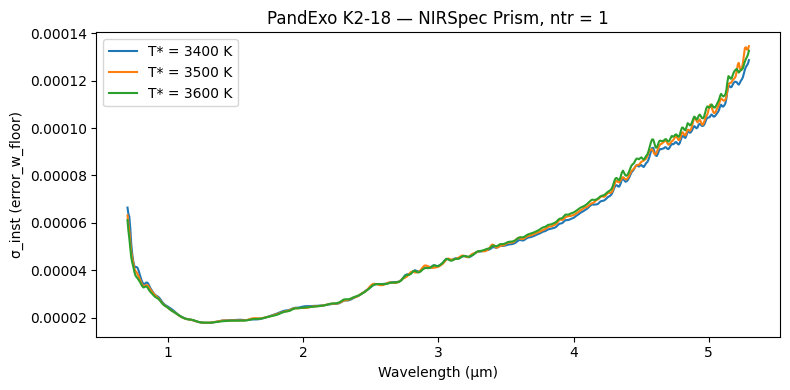

In [13]:
import numpy as np
import matplotlib.pyplot as plt

T_s_values = np.array([3400.0, 3500.0, 3600.0])
colors = ["tab:blue", "tab:orange", "tab:green"]

wl = np.linspace(0.6, 5.3, 1000)
n_transits = 1

plt.figure(figsize=(8, 4))

waves_ref = None
errors_dict = {}

for T_s, color in zip(T_s_values, colors):
    waves_trim, errors_trim = get_k218_prism_noise_flat(
        wl_grid_um=wl,
        n_transits=n_transits,
        T_s=T_s,
        plot=False,       # ya ploteamos nosotros
        cut_first=18,
    )
    errors_dict[T_s] = (waves_trim, errors_trim)

    if waves_ref is None:
        waves_ref = waves_trim  # guardamos para referencia

    plt.plot(
        waves_trim,
        errors_trim,
        label=f"T* = {T_s:.0f} K",
        linewidth=1.5,
    )

plt.xlabel("Wavelength (μm)")
plt.ylabel("σ_inst (error_w_floor)")
plt.title(f"PandExo K2-18 — NIRSpec Prism, ntr = {n_transits}")
plt.legend()
plt.tight_layout()
plt.show()


# Noise


In [14]:
import numpy as np
import pandas as pd
import warnings


def generate_df_with_noise_std(df, n_repeat, noise_std, seed=None):
    """
    Generates a new DataFrame by applying Gaussian noise with the specified standard
    deviation to the spectra in a vectorized manner and concatenates the result with
    another DataFrame containing additional parameter columns.

    Parameters
    ----------
    df : DataFrame
        Must have 'params' and 'data' attributes (df.params, df.data).
    n_repeat : int
        Number of times each spectrum is replicated.
    noise_std : float or array-like
        - Escalar: mismo sigma para todo.
        - 1D de longitud N_spectra: un sigma por espectro (se copia a todas las λ).
        - 1D de longitud N_wavelengths: un sigma por longitud de onda
          (mismo vector sigma_inst para todas las filas).
    seed : int, optional
        Seed for the random number generator.

    Returns
    -------
    df_final : DataFrame
        With 'params' and 'data' attributes como el original.
    """
    # Check for 'params' and 'data' attributes
    if not hasattr(df, "params"):
        print("Warning: 'params' attribute not found in the DataFrame.")
        df_params = pd.DataFrame()
        if not hasattr(df, "data"):
            print(
                "Warning: 'data' attribute not found in the DataFrame. "
                "Assuming the DataFrame contains only spectra."
            )
            df_spectra = df
    else:
        if not hasattr(df, "data"):
            raise ValueError("The DataFrame must have a 'data' attribute.")
        df_params = df.params
        df_spectra = df.data

    # Basic checks
    if not isinstance(df_spectra, pd.DataFrame):
        raise ValueError("df_spectra must be a pandas DataFrame.")
    if not isinstance(df_params, pd.DataFrame):
        raise ValueError("df_params must be a pandas DataFrame.")
    if not isinstance(n_repeat, int) or n_repeat <= 0:
        raise ValueError("n_repeat must be a positive integer.")
    if seed is not None and (not isinstance(seed, int) or seed < 0):
        raise ValueError("seed must be a non-negative integer.")

    n_spec, n_wl = df_spectra.shape

    # Set seed
    if seed is not None:
        np.random.seed(seed)

    # Replicate spectra
    df_spectra_replicated = pd.DataFrame(
        np.repeat(df_spectra.values, n_repeat, axis=0),
        columns=df_spectra.columns,
    )

    # Expand noise_std
    if isinstance(noise_std, (int, float)):
        if noise_std < 0:
            raise ValueError("noise_std must be non-negative.")
        noise_replicated = np.full(df_spectra_replicated.shape, noise_std)
        noise_std_for_params = np.full(n_spec * n_repeat, noise_std)

    elif isinstance(noise_std, (list, np.ndarray, pd.Series)):
        noise_array = np.asarray(noise_std, dtype=float)
        if np.any(noise_array < 0):
            raise ValueError("All values in noise_std must be non-negative.")
        if noise_array.ndim != 1:
            raise ValueError("noise_std must be 1D if array-like.")

        if len(noise_array) == n_spec:
            # Caso antiguo: un sigma por espectro
            base = noise_array[:, np.newaxis]          # (N_spec, 1)
            base = np.repeat(base, n_repeat, axis=0)   # (N_spec * n_repeat, 1)
            noise_replicated = np.tile(base, (1, n_wl))  # (N_spec * n_repeat, N_wl)
            noise_std_for_params = np.repeat(noise_array, n_repeat)

        elif len(noise_array) == n_wl:
            # NUEVO: un sigma por longitud de onda (CASO sigma_inst PandExo)
            noise_replicated = np.tile(noise_array, (n_spec * n_repeat, 1))
            # En params guardamos, por ejemplo, la media del sigma (opcional)
            noise_std_for_params = np.full(n_spec * n_repeat, noise_array.mean())

        else:
            raise ValueError(
                "If noise_std is array-like, its length must be either "
                "N_spectra or N_wavelengths."
            )
    else:
        raise ValueError(
            "noise_std must be a positive number or a 1D list/array/Series."
        )

    # Apply Gaussian noise
    gaussian_noise = np.random.normal(
        loc=0.0,
        scale=noise_replicated,
        size=df_spectra_replicated.shape,
    )
    df_spectra_replicated = df_spectra_replicated + gaussian_noise

    # Replicate params
    df_params_replicated = pd.DataFrame(
        np.repeat(df_params.values, n_repeat, axis=0),
        columns=df_params.columns,
    )

    # Insert 'noise_std' and 'n_repeat'
    df_params_replicated.insert(0, "noise_std", noise_std_for_params)
    df_params_replicated.insert(1, "n_repeat", n_repeat)

    # Concatenate
    df_final = pd.concat(
        [
            df_params_replicated.reset_index(drop=True),
            df_spectra_replicated.reset_index(drop=True),
        ],
        axis=1,
    )

    # Attach attributes
    warnings.filterwarnings("ignore")
    df_final.data = df_final.iloc[:, -df_spectra_replicated.shape[1] :]
    df_final.params = df_final.iloc[:, : df_params_replicated.shape[1]]
    warnings.filterwarnings("default")

    return df_final


# Ruidos

## T= 1


In [15]:
import numpy as np
import pandas as pd
import gc

# ===================== 1) Sigma instrumental para T = 1 =====================
T = 1  # número de tránsitos

wl = np.linspace(0.6, 5.3, 1000)

waves_T1, sigma_T1 = get_k218_prism_noise_flat(
    wl_grid_um=wl,
    n_transits=T,
    T_s=3500.0,
    plot=False,
    cut_first=18,
)
sigma_T1 = sigma_T1[::-1]
# Asegurarnos de que los espectros usan el mismo número de λ que sigma_T1
assert k2_18b_mult.data.shape[1]   == sigma_T1.shape[0]
assert k2_18b_contam.data.shape[1] == sigma_T1.shape[0]

# ===================== 2) DataFrames con y sin contaminación =====================
# El "noisy" para el autoencoder: espectros contaminados + ruido instrumental
# El "clean" para el target: espectros limpios (mult), sin ruido añadido

NREP_T1 = 5  # número de réplicas que quieras (ajustable)

T1_df = generate_df_with_noise_std(
    df=k2_18b_contam,   # entrada ruidosa (contaminada)
    n_repeat=NREP_T1,
    noise_std=sigma_T1, # vector σ_inst(λ) de PandExo
)

T1_df = pd.concat([T1_df,
generate_df_with_noise_std(
    df=flat_contam,   # entrada ruidosa (contaminada)
    n_repeat=NREP_T1*100,
    noise_std=sigma_T1, # vector σ_inst(λ) de PandExo
)])



T1_no_df = generate_df_with_noise_std(
    df=k2_18b_mult,     # objetivo limpio (mult)
    n_repeat=NREP_T1,
    noise_std=0.0,      # sin ruido adicional, solo se replican las filas
)

T1_no_df = pd.concat([T1_no_df,
generate_df_with_noise_std(
    df=flat_mult,     # objetivo limpio (mult)
    n_repeat=NREP_T1*100,
    noise_std=0.0,      # sin ruido adicional, solo se replican las filas
)])



print("Clean and noisy dataframes have the same shape:",
      T1_df.shape == T1_no_df.shape)

gc.collect()


Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
Clean and noisy dataframes have the same shape: True


3844

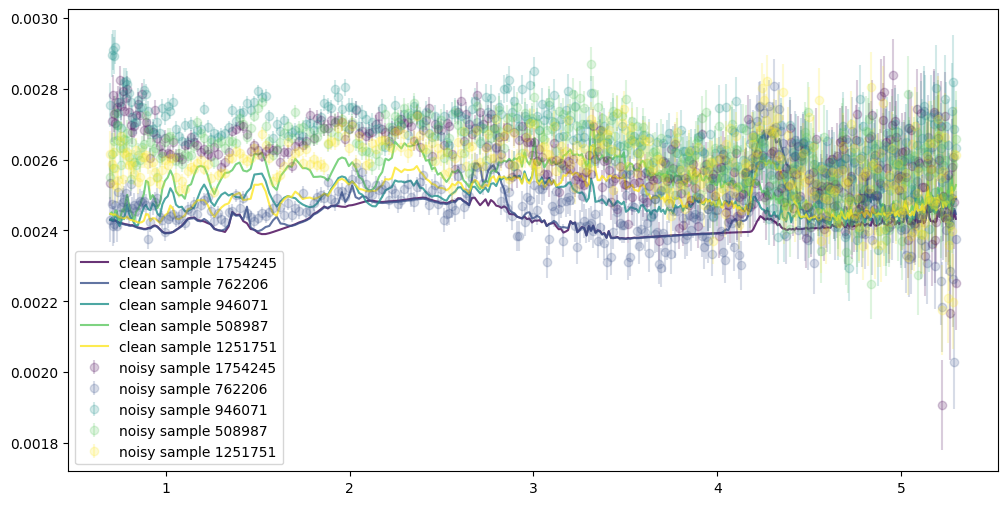

In [16]:
## plot samples of T1
plt.figure(figsize=(12, 6))
# five colors
colors = plt.cm.viridis(np.linspace(0, 1, 5))

columns = T1_df.columns[-n_points:]
for _ in range(5):
    idx = np.random.randint(0, T1_df.shape[0])
    plt.errorbar(columns, T1_df.iloc[idx, -n_points:],
    yerr=sigma_T1,
    alpha=0.2, label=f"noisy sample {idx}",
    color=colors[_],
    fmt='o',
    )

    plt.plot(T1_no_df.iloc[idx, -n_points:],
    alpha=0.8, label=f"clean sample {idx}",
    color=colors[_]
    )

plt.legend()
plt.show()


In [17]:
T1_df[["atm CO2","atm NH3", "atm CH4", "atm H2O"]].value_counts()

atm CO2  atm NH3  atm CH4  atm H2O
 0.0      0.0      0.0      0.0       8000
-4.0     -3.0     -3.0     -2.0        400
                  -2.0     -3.0        400
                           -4.0        400
                           -5.0        400
                                      ... 
-7.0     -5.0     -5.0      0.0        400
                  -4.0     -7.0        400
                           -6.0        400
                           -5.0        400
-5.0     -7.0     -8.0     -7.0        400
Name: count, Length: 4411, dtype: int64

## T = 2

In [18]:
import numpy as np
import pandas as pd
import gc

# ===================== 1) Sigma instrumental para T = 2 =====================
T = 2  # número de tránsitos

wl = np.linspace(0.6, 5.3, 1000)

waves_T2, sigma_T2 = get_k218_prism_noise_flat(
    wl_grid_um=wl,
    n_transits=T,
    T_s=3500.0,
    plot=False,
    cut_first=18,
)

sigma_T2 = sigma_T2[::-1]

# Asegurarnos de que los espectros usan el mismo número de λ que sigma_T2
assert k2_18b_mult.data.shape[1]   == sigma_T2.shape[0]
assert k2_18b_contam.data.shape[1] == sigma_T2.shape[0]

# ===================== 2) DataFrames con y sin contaminación =====================
# El "noisy" para el autoencoder: espectros contaminados + ruido instrumental
# El "clean" para el target: espectros limpios (mult), sin ruido añadido

NREP_T2 = 5  # número de réplicas que quieras (ajustable)

T2_df = generate_df_with_noise_std(
    df=k2_18b_contam,   # entrada ruidosa (contaminada)
    n_repeat=NREP_T2,
    noise_std=sigma_T2, # vector σ_inst(λ) de PandExo
)

T2_df = pd.concat([T2_df,
generate_df_with_noise_std(
    df=flat_contam,   # entrada ruidosa (contaminada)
    n_repeat=NREP_T2*100,
    noise_std=sigma_T2, # vector σ_inst(λ) de PandExo
)])



T2_no_df = generate_df_with_noise_std(
    df=k2_18b_mult,     # objetivo limpio (mult)
    n_repeat=NREP_T2,
    noise_std=0.0,      # sin ruido adicional, solo se replican las filas
)

T2_no_df = pd.concat([T2_no_df,
generate_df_with_noise_std(
    df=flat_mult,     # objetivo limpio (mult)
    n_repeat=NREP_T2*100,
    noise_std=0.0,      # sin ruido adicional, solo se replican las filas
)])



print("Clean and noisy dataframes have the same shape:",
      T2_df.shape == T2_no_df.shape)

gc.collect()


Running Single Case w/ User Instrument Dict


c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:988: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:1251: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2958: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2910: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()


Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]
c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:
c:\Users\User\anaconda3\Lib\site-packages\pandexo\engine\jwst.py:176: ResourceWarning: unclosed file <_io.BufferedReader name='C:\\Proyectos\\Astro\\Pandexo\\pandeia_data-3.0rc3\\jwst\\nirspec\\qe\\jwst_nirspec_qe_20160902193401.fits'>
  out = remove_QY(out, instrument)
c:\Users\User\anaconda3\Lib\site-packages\pandexo\engine\justdoit.py:394: ResourceWarning: unclosed file <_io.BufferedWriter name='c:\\Proyectos\\Astro\\AEspectra\\exp 3\\singlerun.p'>
  if save_file: pkl.dump(results, open(os.path.join(output_path,output_file),'wb'))


End out of Transit
Starting In Transit Simulation
End In Transit
Clean and noisy dataframes have the same shape: True


8194

## T = 4

In [19]:
import numpy as np
import pandas as pd
import gc

# ===================== 1) Sigma instrumental para T = 4 =====================
T = 4  # número de tránsitos

wl = np.linspace(0.6, 5.3, 1000)

waves_T4, sigma_T4 = get_k218_prism_noise_flat(
    wl_grid_um=wl,
    n_transits=T,
    T_s=3500.0,
    plot=False,
    cut_first=18,
)
sigma_T4 = sigma_T4[::-1]
# Asegurarnos de que los espectros usan el mismo número de λ que sigma_T4
assert k2_18b_mult.data.shape[1]   == sigma_T4.shape[0]
assert k2_18b_contam.data.shape[1] == sigma_T4.shape[0]

# ===================== 2) DataFrames con y sin contaminación =====================
# El "noisy" para el autoencoder: espectros contaminados + ruido instrumental
# El "clean" para el target: espectros limpios (mult), sin ruido añadido

NREP_T4 = 5  # número de réplicas que quieras (ajustable)

T4_df = generate_df_with_noise_std(
    df=k2_18b_contam,   # entrada ruidosa (contaminada)
    n_repeat=NREP_T4,
    noise_std=sigma_T4, # vector σ_inst(λ) de PandExo
)

T4_df = pd.concat([T4_df,
generate_df_with_noise_std(
    df=flat_contam,   # entrada ruidosa (contaminada)
    n_repeat=NREP_T4*100,
    noise_std=sigma_T4, # vector σ_inst(λ) de PandExo
)])



T4_no_df = generate_df_with_noise_std(
    df=k2_18b_mult,     # objetivo limpio (mult)
    n_repeat=NREP_T4,
    noise_std=0.0,      # sin ruido adicional, solo se replican las filas
)

T4_no_df = pd.concat([T4_no_df,
generate_df_with_noise_std(
    df=flat_mult,     # objetivo limpio (mult)
    n_repeat=NREP_T4*100,
    noise_std=0.0,      # sin ruido adicional, solo se replican las filas
)])



print("Clean and noisy dataframes have the same shape:",
      T4_df.shape == T4_no_df.shape)

gc.collect()


Running Single Case w/ User Instrument Dict


c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:988: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:1251: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2958: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()
c:\Users\User\anaconda3\Lib\site-packages\pysynphot\spectrum.py:2910: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  self.validate_wavetable()


Starting Out of Transit Simulation


        Use "format" instead. [pandeia.engine.extinction]
c:\Users\User\anaconda3\Lib\site-packages\pandeia\engine\report.py:1012: RuntimeWarning: divide by zero encountered in log
  if np.log(abs(val)) < -1*precision and val != 0.0:
c:\Users\User\anaconda3\Lib\site-packages\pandexo\engine\jwst.py:176: ResourceWarning: unclosed file <_io.BufferedReader name='C:\\Proyectos\\Astro\\Pandexo\\pandeia_data-3.0rc3\\jwst\\nirspec\\qe\\jwst_nirspec_qe_20160902193401.fits'>
  out = remove_QY(out, instrument)
c:\Users\User\anaconda3\Lib\site-packages\pandexo\engine\justdoit.py:394: ResourceWarning: unclosed file <_io.BufferedWriter name='c:\\Proyectos\\Astro\\AEspectra\\exp 3\\singlerun.p'>
  if save_file: pkl.dump(results, open(os.path.join(output_path,output_file),'wb'))


End out of Transit
Starting In Transit Simulation
End In Transit
Clean and noisy dataframes have the same shape: True


478

## T = Nan

In [20]:
import numpy as np
import pandas as pd
import gc



# ===================== 2) DataFrames con y sin contaminación =====================
# El "noisy" para el autoencoder: espectros contaminados + ruido instrumental
# El "clean" para el target: espectros limpios (mult), sin ruido añadido

NREP_TNaN = 7  # número de réplicas que quieras (ajustable)

TNaN_df = generate_df_with_noise_std(
    df=k2_18b_contam,   # entrada ruidosa (contaminada)
    n_repeat=NREP_TNaN,
    noise_std=0.0, # vector σ_inst(λ) de PandExo
)

TNaN_df = pd.concat([TNaN_df,
generate_df_with_noise_std(
    df=flat_contam,   # entrada ruidosa (contaminada)
    n_repeat=NREP_TNaN*100,
    noise_std=0.0, # vector σ_inst(λ) de PandExo
)])



TNaN_no_df = generate_df_with_noise_std(
    df=k2_18b_mult,     # objetivo limpio (mult)
    n_repeat=NREP_TNaN,
    noise_std=0.0,      # sin ruido adicional, solo se replican las filas
)

TNaN_no_df = pd.concat([TNaN_no_df,
generate_df_with_noise_std(
    df=flat_mult,     # objetivo limpio (mult)
    n_repeat=NREP_TNaN*100,
    noise_std=0.0,      # sin ruido adicional, solo se replican las filas
)])



print("Clean and noisy dataframes have the same shape:",
      TNaN_df.shape == TNaN_no_df.shape)

gc.collect()


Clean and noisy dataframes have the same shape: True


0

## Data 

In [15]:
import numpy as np

wl = np.linspace(0.6, 5.3, 1000)  # tu grid base

sigma_by_T = {}

for T in [1, 2, 4]:
    _, sigma_T = get_k218_prism_noise_flat(
        wl_grid_um=wl,
        n_transits=T,
        T_s=3500.0,
        plot=False,
        cut_first=18,
    )
    sigma_by_T[T] = sigma_T[::-1]

# Para chequear consistencia:
n_points = sigma_by_T[1].shape[0]
assert k2_18b_mult.data.shape[1]   == n_points
assert k2_18b_contam.data.shape[1] == n_points
assert flat_mult.data.shape[1]     == n_points
assert flat_contam.data.shape[1]   == n_points


Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit


In [16]:
import gc
import numpy as np
import pandas as pd

def build_block_for_T(
    T_label,
    sigma_T,
    n_repeat_main,
    flat_factor,
    add_instrument_noise=True,
):
    """
    Construye X_noisy_T y X_clean_T para un valor de T dado.

    - n_repeat_main: cuántas veces repetir los espectros "reales"
                     (k2_18b_contam / k2_18b_mult)
    - flat_factor: multiplicador para los flats (flat_*),
                   el mismo para noisy y clean.
    """

    # nº de réplicas para cada grupo
    n_main = n_repeat_main
    n_flat = n_repeat_main * flat_factor

    # =====================================================
    # 1) NOISY  (contaminada + ruido instrumental opcional)
    # =====================================================
    if add_instrument_noise:
        noise_std_contam = sigma_T     # vector σ(λ) de PandExo
    else:
        noise_std_contam = 0.0         # sin ruido instrumental

    df_noisy_main = generate_df_with_noise_std(
        df=k2_18b_contam,
        n_repeat=n_main,
        noise_std=noise_std_contam,
    )

    df_noisy_flat = generate_df_with_noise_std(
        df=flat_contam,
        n_repeat=n_flat,
        noise_std=noise_std_contam,
    )

    # Tamaños de params/data ANTES del concat
    n_param_cols = df_noisy_main.params.shape[1]
    n_spec_cols  = df_noisy_main.data.shape[1]

    df_noisy_all = pd.concat(
        [df_noisy_main, df_noisy_flat],
        ignore_index=True
    )

    # Volver a definir .params y .data tras el concat
    df_noisy_all.params = df_noisy_all.iloc[:, :n_param_cols]
    df_noisy_all.data   = df_noisy_all.iloc[:, -n_spec_cols:]

    # =====================================================
    # 2) CLEAN  (mult, sin ruido)
    # =====================================================
    df_clean_main = generate_df_with_noise_std(
        df=k2_18b_mult,
        n_repeat=n_main,
        noise_std=0.0,
    )

    df_clean_flat = generate_df_with_noise_std(
        df=flat_mult,
        n_repeat=n_flat,
        noise_std=0.0,
    )

    n_param_cols_clean = df_clean_main.params.shape[1]
    n_spec_cols_clean  = df_clean_main.data.shape[1]

    df_clean_all = pd.concat(
        [df_clean_main, df_clean_flat],
        ignore_index=True
    )

    df_clean_all.params = df_clean_all.iloc[:, :n_param_cols_clean]
    df_clean_all.data   = df_clean_all.iloc[:, -n_spec_cols_clean:]

    # =====================================================
    # 3) Consistencia de formas
    # =====================================================
    assert df_noisy_all.shape[0]      == df_clean_all.shape[0],  "Noisy/Clean rows mismatch"
    assert df_noisy_all.data.shape[1] == df_clean_all.data.shape[1], "Noisy/Clean cols mismatch"

    # =====================================================
    # 4) Normalización fila a fila "como tú la haces"
    #    (primero noisy, luego clean)
    # =====================================================

    # ------- NOISY -------
    spec_noisy_df = df_noisy_all.data.copy()

    min_by_row_n = spec_noisy_df.min(axis=1)
    max_by_row_n = spec_noisy_df.max(axis=1)
    range_by_row_n = max_by_row_n - min_by_row_n

    spec_noisy_norm = spec_noisy_df.sub(min_by_row_n, axis=0).div(range_by_row_n, axis=0)
    # donde rango == 0, poner todo a 0
    mask_n = (range_by_row_n == 0)
    if mask_n.any():
        spec_noisy_norm.loc[mask_n, :] = 0

    spec_noisy = spec_noisy_norm.values.astype("float32")

    # ------- CLEAN -------
    spec_clean_df = df_clean_all.data.copy()

    min_by_row_c = spec_clean_df.min(axis=1)
    max_by_row_c = spec_clean_df.max(axis=1)
    range_by_row_c = max_by_row_c - min_by_row_c

    spec_clean_norm = spec_clean_df.sub(min_by_row_c, axis=0).div(range_by_row_c, axis=0)
    mask_c = (range_by_row_c == 0)
    if mask_c.any():
        spec_clean_norm.loc[mask_c, :] = 0

    spec_clean = spec_clean_norm.values.astype("float32")

    # Etiquetas de T (por si las quieres usar luego)
    T_vec = np.full(spec_noisy.shape[0], T_label)

    # =====================================================
    # 5) Limpiar RAM
    # =====================================================
    del (df_noisy_main, df_noisy_flat, df_noisy_all,
         df_clean_main, df_clean_flat, df_clean_all,
         spec_noisy_df, spec_clean_df,
         spec_noisy_norm, spec_clean_norm)
    gc.collect()

    return spec_noisy, spec_clean, T_vec


In [17]:
# Primero calculas los sigma_T una vez
wl = np.linspace(0.6, 5.3, 1000)
sigma_by_T = {}
for T in [1, 2, 4]:
    _, sigma_T = get_k218_prism_noise_flat(
        wl_grid_um=wl,
        n_transits=T,
        T_s=3500.0,
        plot=False,
        cut_first=18,
    )
    sigma_by_T[T] = sigma_T

# Ahora construyes bloques por T
X_noisy_list = []
X_clean_list = []
T_labels_list = []

# T = 1, 2, 4 con ruido instrumental
for T_val in [1, 2, 4]:
    Xn, Xc, Tl = build_block_for_T(
        T_label=T_val,
        sigma_T=sigma_by_T[T_val],
        n_repeat_main=5,
        flat_factor=100,          # <- un solo factor para flats
        add_instrument_noise=True,
    )
    X_noisy_list.append(Xn)
    X_clean_list.append(Xc)
    T_labels_list.append(Tl)

# T = NaN (sin ruido instrumental, solo contaminación estelar/base)
Xn, Xc, Tl = build_block_for_T(
    T_label=np.nan,
    sigma_T=None,      # no se usa si add_instrument_noise=False
    n_repeat_main=7,
    flat_factor=70,
    add_instrument_noise=False,
)
X_noisy_list.append(Xn)
X_clean_list.append(Xc)
T_labels_list.append(Tl)

# Concatenas arrays finales
X_noisy  = np.vstack(X_noisy_list)
X_clean  = np.vstack(X_clean_list)
T_labels = np.concatenate(T_labels_list)

print("Final shapes:", X_noisy.shape, X_clean.shape)
assert X_noisy.shape == X_clean.shape


Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit
Running Single Case w/ User Instrument Dict
Starting Out of Transit Simulation
End out of Transit
Starting In Transit Simulation
End In Transit


C:\Users\User\AppData\Local\Temp\ipykernel_15556\2944823614.py:55: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_noisy_all.params = df_noisy_all.iloc[:, :n_param_cols]
C:\Users\User\AppData\Local\Temp\ipykernel_15556\2944823614.py:56: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_noisy_all.data   = df_noisy_all.iloc[:, -n_spec_cols:]
C:\Users\User\AppData\Local\Temp\ipykernel_15556\2944823614.py:81: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_clean_all.params = df_clean_all.iloc[:, :n_param_cols_clean]
C:\Users\User\AppData\Local\Temp\ipykernel_15556\2944823614.py:82: UserWarning: Pandas doesn't allow columns to be created v

Final shapes: (7793440, 385) (7793440, 385)


In [18]:
# opcional: asegurar que están en float32 para ahorrar espacio
X_noisy  = X_noisy.astype("float32")
X_clean  = X_clean.astype("float32")

np.savez_compressed(
    "k218_autoencoder_dataset.npz",
    X_noisy=X_noisy,
    X_clean=X_clean,
    T_labels=T_labels,
)


### FInal data

In [19]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


<frozen importlib._bootstrap>:488: DeprecationWarning: Type google.protobuf.pyext._message.ScalarMapContainer uses PyType_Spec with a metaclass that has custom tp_new. This is deprecated and will no longer be allowed in Python 3.14.
<frozen importlib._bootstrap>:488: DeprecationWarning: Type google.protobuf.pyext._message.MessageMapContainer uses PyType_Spec with a metaclass that has custom tp_new. This is deprecated and will no longer be allowed in Python 3.14.


In [20]:
from sklearn.model_selection import train_test_split
import gc

test_size = 0.2  

X_train_noisy, X_test_noisy, X_train_clean, X_test_clean = train_test_split(
    X_noisy,
    X_clean,
    test_size=test_size,
    random_state=42,   # opcional, solo para reproducibilidad
)

del X_noisy, X_clean
gc.collect()


10

### Autoencoder 

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

# Define input dimension (number of points in the spectrum)
input_dim = X_train_noisy.shape[1]

# Un valor común para empezar con la regularización L2
l2_lambda = 1e-7

# Define model input
input_spectrum = keras.Input(shape=(input_dim,))

# Encoder
encoded = layers.Dense(512, activation='swish', kernel_regularizer=keras.regularizers.l2(l2_lambda))(input_spectrum)
encoded = layers.Dropout(0.5)(encoded)
encoded = layers.Dense(512, activation='swish', kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
encoded = layers.Dropout(0.5)(encoded)
encoded = layers.Dense(512, activation='swish', kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
encoded = layers.Dropout(0.5)(encoded)
encoded = layers.Dense(300, activation='swish', kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
encoded = layers.Dropout(0.5)(encoded)
encoded = layers.Dense(300, activation='swish', kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
encoded = layers.Dropout(0.5)(encoded)

# Decoder
decoded = layers.Dense(300, activation='swish', kernel_regularizer=keras.regularizers.l2(l2_lambda))(encoded)
decoded = layers.Dropout(0.5)(decoded)
decoded = layers.Dense(300, activation='swish', kernel_regularizer=keras.regularizers.l2(l2_lambda))(decoded)
decoded = layers.Dropout(0.5)(decoded)
decoded = layers.Dense(512, activation='swish', kernel_regularizer=keras.regularizers.l2(l2_lambda))(decoded)
decoded = layers.Dropout(0.5)(decoded)
decoded = layers.Dense(512, activation='swish', kernel_regularizer=keras.regularizers.l2(l2_lambda))(decoded)
decoded = layers.Dropout(0.5)(decoded)
decoded = layers.Dense(512, activation='swish', kernel_regularizer=keras.regularizers.l2(l2_lambda))(decoded)
decoded = layers.Dropout(0.5)(decoded)
decoded = layers.Dense(input_dim, activation='linear')(decoded) # Usualmente no se regulariza la última capa de salida

# Build autoencoder model
autoencoder = keras.Model(inputs=input_spectrum, outputs=decoded)

# Define optimizer with a custom learning rate
optimizer = Adam(learning_rate=1e-5)

# Compile the model with MAE loss
autoencoder.compile(optimizer=optimizer, loss='mae')

# Print model summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 385)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       153,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       154,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 385)            │       197,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,024,673 (7.72 MB)

 Trainable params: 2,024,673 (7.72 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 841s 9ms/step - loss: 0.1093 - val_loss: 0.0544
Epoch 2/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 838s 9ms/step - loss: 0.0672 - val_loss: 0.0396
Epoch 3/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 844s 9ms/step - loss: 0.0538 - val_loss: 0.0318
Epoch 4/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 846s 9ms/step - loss: 0.0451 - val_loss: 0.0285
Epoch 5/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 848s 9ms/step - loss: 0.0423 - val_loss: 0.0259
Epoch 6/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 850s 9ms/step - loss: 0.0404 - val_loss: 0.0243
Epoch 7/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 846s 9ms/step - loss: 0.0390 - val_loss: 0.0229
Epoch 8/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 847s 9ms/step - loss: 0.0378 - val_loss: 0.0221
Epoch 9/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 848s 9ms/step - loss: 0.0369 - val_loss: 0.0212
Epoch 10/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 849s 9ms/step - loss: 0.0360 - val_loss: 0.0211
Epoch 11/100
97418/97418 ━━━━━━━━━━━━━━━━━━━━ 850s 9ms/step - loss: 0

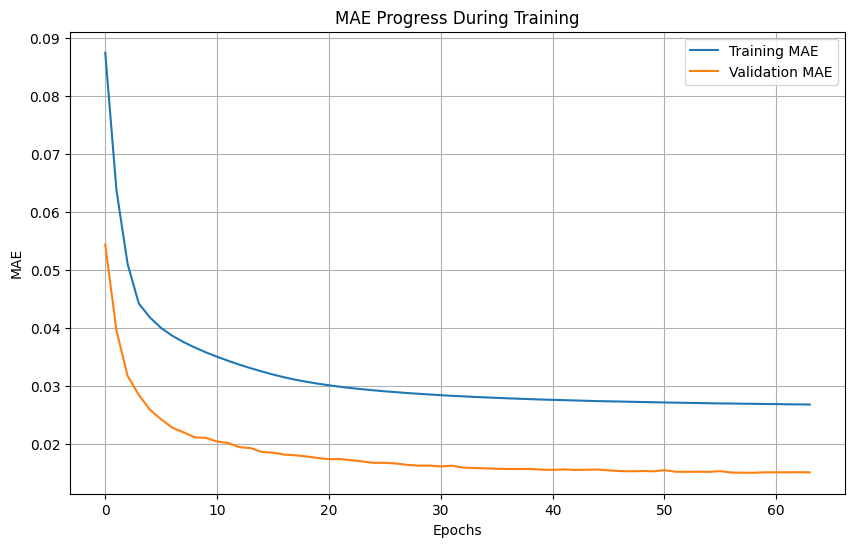

48709/48709 ━━━━━━━━━━━━━━━━━━━━ 306s 6ms/step


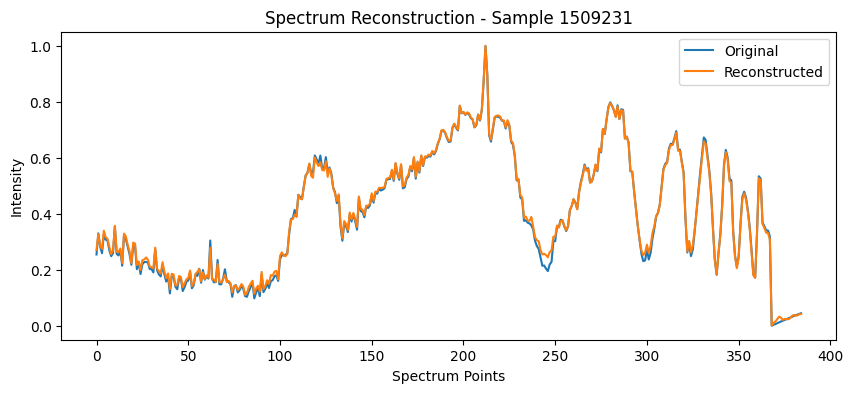

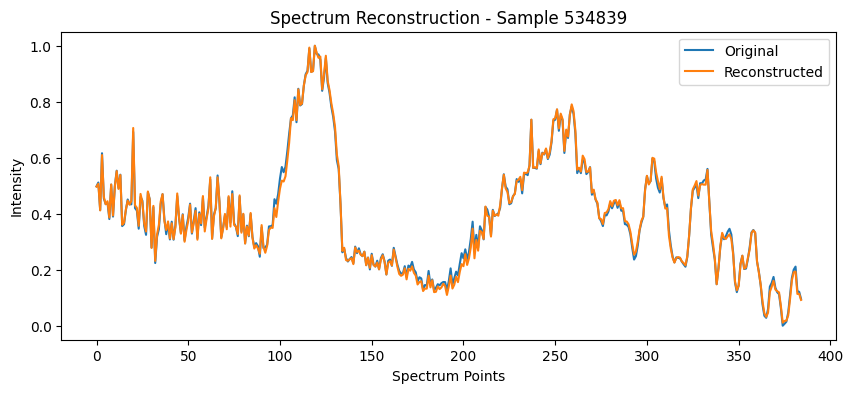

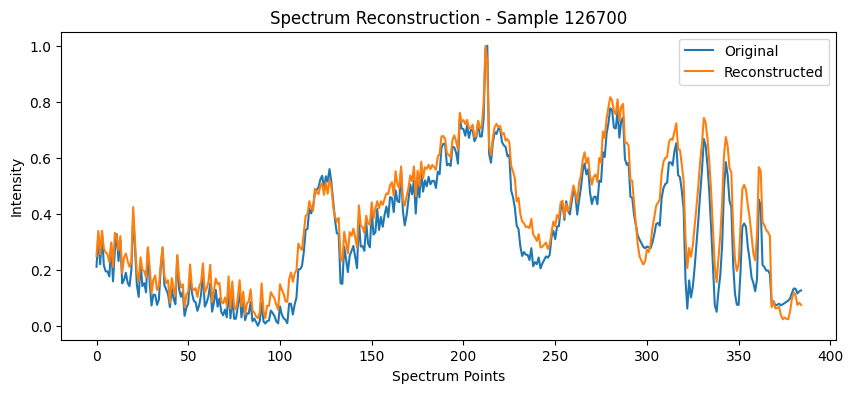

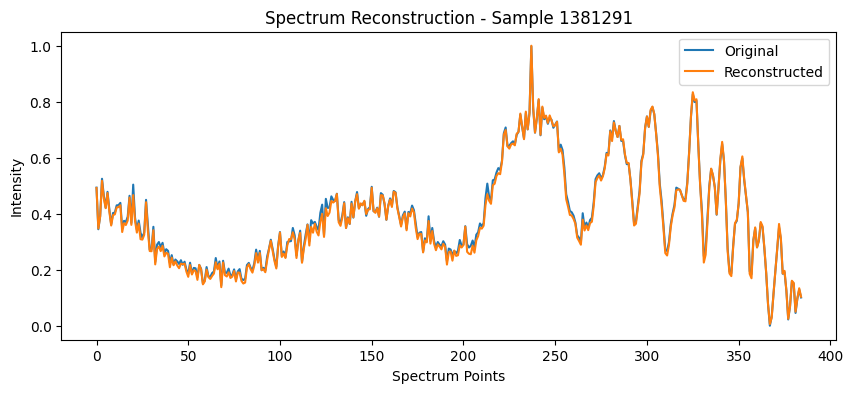

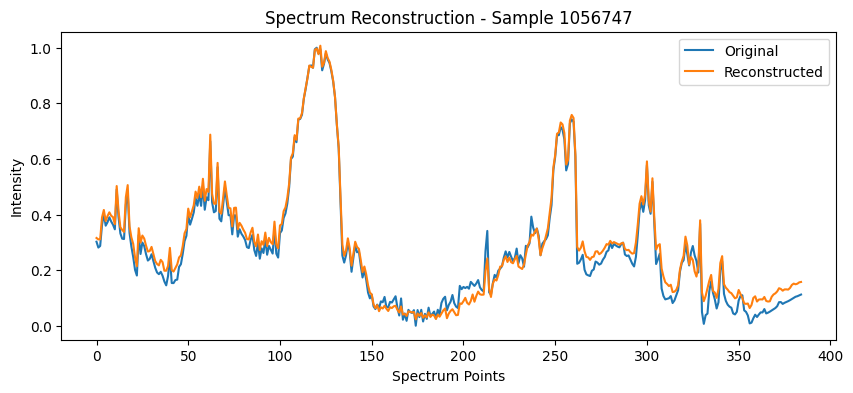

In [22]:
# Train the autoencoder
history = autoencoder.fit(
    X_train_noisy,
    X_train_clean,
    epochs=100,
    batch_size=64,
    shuffle=True,
    validation_data=(X_test_noisy, X_test_clean),
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )
    ],
)

# Save the trained model
autoencoder.save("AE.keras")

# Plot training and validation MAE
plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Training MAE")
plt.plot(history.history["val_loss"], label="Validation MAE")
plt.title("MAE Progress During Training")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

# Predict reconstructed spectra on test data
decoded_spectra = autoencoder.predict(X_test_noisy)

# Visualize a few reconstructions
num_samples = 5  # Number of samples to visualize
indices = np.random.choice(len(X_test_noisy), num_samples, replace=False)

for idx in indices:
    plt.figure(figsize=(10, 4))
    plt.plot(X_test_clean[idx].flatten(), label="Original")
    plt.plot(decoded_spectra[idx].flatten(), label="Reconstructed")
    plt.xlabel("Spectrum Points")
    plt.ylabel("Intensity")
    plt.title(f"Spectrum Reconstruction - Sample {idx}")
    plt.legend()
    plt.show()


In [ ]:
""" import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

# Define input dimension (number of points in the spectrum)
input_dim = X_train_noisy.shape[1]

# Define model input
input_spectrum = keras.Input(shape=(input_dim,))

# Encoder
encoded = layers.Dense(512, activation='swish')(input_spectrum)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(512, activation='swish')(encoded)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(512, activation='swish')(encoded)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(300, activation='swish')(encoded)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(300, activation='swish')(encoded)
encoded = layers.Dropout(0.2)(encoded)

# Decoder
decoded = layers.Dense(300, activation='swish')(encoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(300, activation='swish')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(512, activation='swish')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(512, activation='swish')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(512, activation='swish')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(input_dim, activation='linear')(decoded)

# Build autoencoder model
autoencoder = keras.Model(inputs=input_spectrum, outputs=decoded)

# Define optimizer with a custom learning rate
optimizer = Adam(learning_rate=1e-5)

# Compile the model with MAE loss
autoencoder.compile(optimizer=optimizer, loss='mae')

# Print model summary
autoencoder.summary()
 """

" import tensorflow as tf\nfrom tensorflow import keras\nfrom tensorflow.keras import layers\nfrom tensorflow.keras.optimizers import Adam\n\n# Define input dimension (number of points in the spectrum)\ninput_dim = X_train_noisy.shape[1]\n\n# Define model input\ninput_spectrum = keras.Input(shape=(input_dim,))\n\n# Encoder\nencoded = layers.Dense(512, activation='swish')(input_spectrum)\nencoded = layers.Dropout(0.2)(encoded)\nencoded = layers.Dense(512, activation='swish')(encoded)\nencoded = layers.Dropout(0.2)(encoded)\nencoded = layers.Dense(512, activation='swish')(encoded)\nencoded = layers.Dropout(0.2)(encoded)\nencoded = layers.Dense(300, activation='swish')(encoded)\nencoded = layers.Dropout(0.2)(encoded)\nencoded = layers.Dense(300, activation='swish')(encoded)\nencoded = layers.Dropout(0.2)(encoded)\n\n# Decoder\ndecoded = layers.Dense(300, activation='swish')(encoded)\ndecoded = layers.Dropout(0.2)(decoded)\ndecoded = layers.Dense(300, activation='swish')(decoded)\ndecoded 

# Eval

In [23]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras

# Load the trained autoencoder model and reconstruct the test spectra
#autoencoder = keras.models.load_model("AE.keras")
X_reconstructed = autoencoder.predict(X_test_noisy)

# Compute evaluation metrics on the test set
mae = mean_absolute_error(X_test_clean, X_reconstructed)
print(f"Mean Absolute Error (MAE): {mae:.6f}")

mse = mean_squared_error(X_test_clean, X_reconstructed)
print(f"Mean Squared Error (MSE): {mse:.6f}")

r2 = r2_score(X_test_clean, X_reconstructed)
print(f"Coefficient of Determination (R²): {r2:.6f}")

48709/48709 ━━━━━━━━━━━━━━━━━━━━ 312s 6ms/step
Mean Absolute Error (MAE): 0.014487
Mean Squared Error (MSE): 0.000534
Coefficient of Determination (R²): 0.975199


<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_15556\3433328091.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('Wavelength ($\mu$m)')


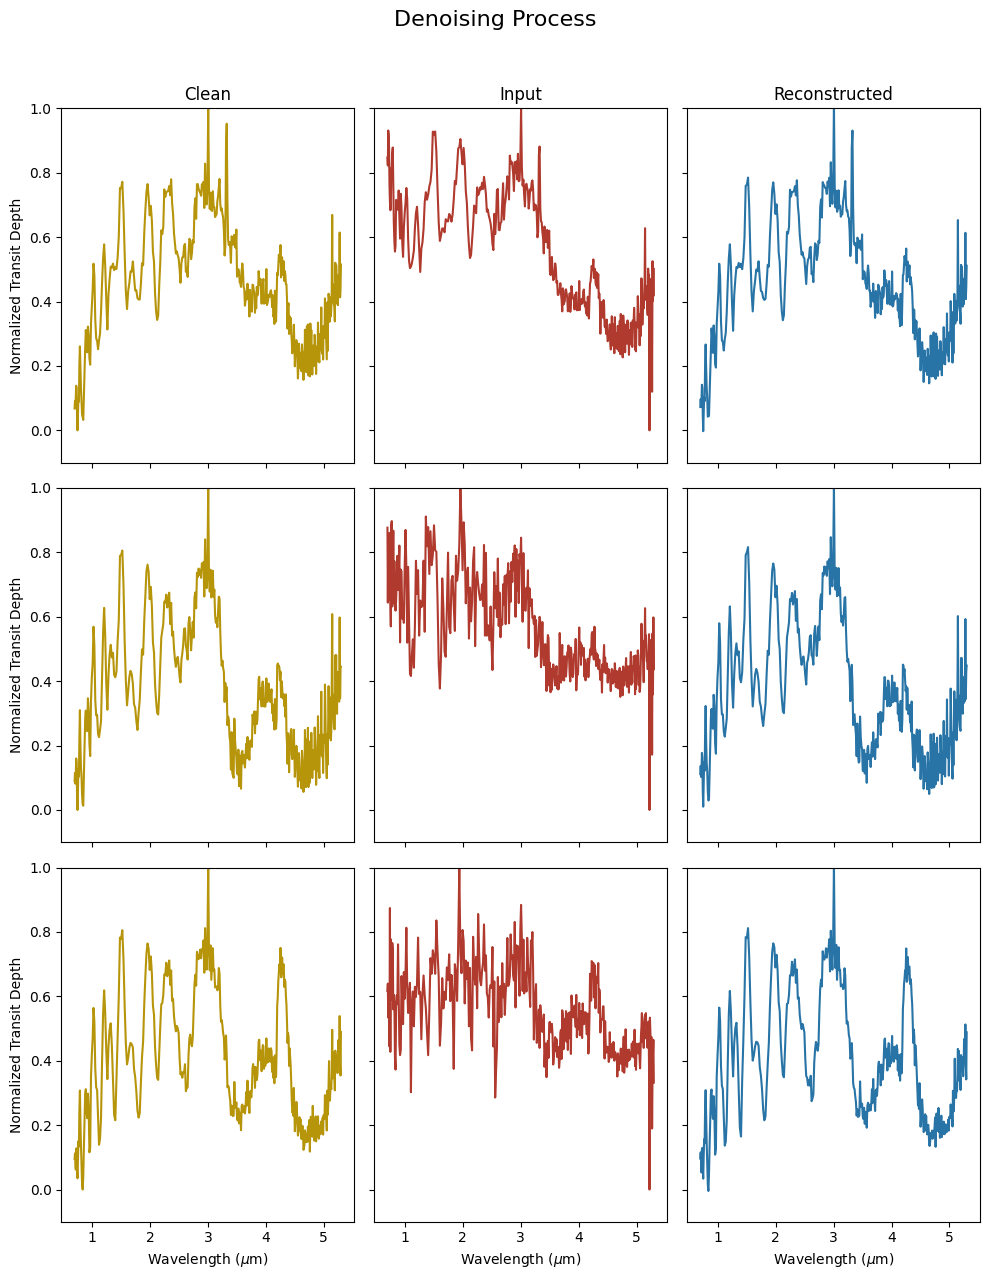

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Colors for the spectra
clean_color = "#B7950B"  # CH4 base color
input_color = "#B03A2E"  # O3 base color
reconstructed_color = "#2874A6"  # H2O base color

# Select some random samples for visualization
num_samples = 3
indices = np.random.choice(X_test_noisy.shape[0], num_samples, replace=False)

# Create subplots
fig, axes = plt.subplots(num_samples, 3, figsize=(10, 13), sharex=True, sharey=True)
fig.suptitle('Denoising Process', fontsize=16)

# Column titles
columns = ['Clean', 'Input', 'Reconstructed']

# Plot the spectra
for i, idx in enumerate(indices):
    # Clean Spectrum
    axes[i, 0].plot(waves[::-1], X_test_clean[idx], color=clean_color)
    axes[i, 0].set_ylim(-0.1, 1)
    axes[i, 0].set_title(columns[0] if i == 0 else None)
    axes[i, 0].set_ylabel('Normalized Transit Depth')
    
    # Input Spectrum
    axes[i, 1].plot(waves[::-1], X_test_noisy[idx], color=input_color)
    axes[i, 1].set_ylim(-0.1, 1)
    axes[i, 1].set_title(columns[1] if i == 0 else None)
    
    # Reconstructed Spectrum
    axes[i, 2].plot(waves[::-1], X_reconstructed[idx], color=reconstructed_color)
    axes[i, 2].set_ylim(-0.1, 1)
    axes[i, 2].set_title(columns[2] if i == 0 else None)

# X-axis label
for ax in axes[-1, :]:
    ax.set_xlabel('Wavelength ($\mu$m)')

plt.tight_layout(rect=[0, 0, 1, 0.96])

## save as .svg file
#plt.savefig('fotos/autoencoder.svg', format='svg', dpi=300)
plt.show()


